# 15 — Contributions Tier 4 : QKAM, Phase diagram, Concept drift

Trois analyses frontiere, a la limite de ce qui est publie dans la litterature QMKL :

| # | Analyse | Apport |
|---|---------|--------|
| **A** | QKAM — Quantum Kernel Attention | Poids de kernel adaptatifs par instance (mecanisme d'attention) |
| **P** | Phase diagram avantage quantique | Carte (separabilite x bruit) : quand le quantique gagne-t-il ? |
| **C** | Concept drift robustness | Stabilite temporelle des poids MKL face aux shifts de distribution |

In [1]:
import sys, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import OrderedDict
from sklearn.datasets import make_classification
warnings.filterwarnings('ignore')

ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))

from data.loaders import load_dataset
from src.preprocessing import QuantumScaler, FeatureReducer
from src.mkl.alignment import centered_alignment

OUT = ROOT / 'results' / '15'
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 11, 'axes.titlesize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.bbox': 'tight',
})

SEED = 42
Q    = 6
print(f'Configuration : Q={Q}, SEED={SEED}')
print(f'Resultats -> {OUT}')

Configuration : Q=6, SEED=42
Resultats -> C:\Users\Raph\Desktop\QMKL-Finance\results\15


In [2]:
from qiskit.circuit.library import PauliFeatureMap
from qiskit.quantum_info import Statevector
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.ensemble import RandomForestClassifier

def fidelity_kernel(fm, X):
    params = list(fm.parameters)
    dim = 2 ** fm.num_qubits
    svs = np.zeros((len(X), dim), dtype=complex)
    for i, x in enumerate(X):
        svs[i] = Statevector.from_instruction(
            fm.assign_parameters({p: float(v) for p, v in zip(params, x)})
        ).data
    return np.abs(svs @ svs.conj().T) ** 2

def make_psd(K, eps=1e-8):
    lam = np.linalg.eigvalsh(K).min()
    if lam < 0:
        K = K + (abs(lam) + eps) * np.eye(K.shape[0])
    return K

# Bibliotheque de 12 kernels (Q=6)
FM_LIB = OrderedDict([
    ('Z a=1.0',     PauliFeatureMap(Q, reps=1, paulis=['Z'],       alpha=1.0, entanglement='linear')),
    ('Z a=3.0',     PauliFeatureMap(Q, reps=1, paulis=['Z'],       alpha=3.0, entanglement='linear')),
    ('ZZ a=1.0',    PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'],  alpha=1.0, entanglement='linear')),
    ('ZZ a=4.0',    PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'],  alpha=4.0, entanglement='linear')),
    ('XZ a=0.5',    PauliFeatureMap(Q, reps=1, paulis=['X','Z'],   alpha=0.5, entanglement='linear')),
    ('XZ a=2.5',    PauliFeatureMap(Q, reps=1, paulis=['X','Z'],   alpha=2.5, entanglement='linear')),
    ('YXX a=0.6',   PauliFeatureMap(Q, reps=1, paulis=['Y','XX'],  alpha=0.6, entanglement='linear')),
    ('YXX a=3.0',   PauliFeatureMap(Q, reps=1, paulis=['Y','XX'],  alpha=3.0, entanglement='linear')),
    ('YZX a=0.6',   PauliFeatureMap(Q, reps=1, paulis=['Y','ZX'],  alpha=0.6, entanglement='linear')),
    ('YZX a=3.0',   PauliFeatureMap(Q, reps=1, paulis=['Y','ZX'],  alpha=3.0, entanglement='linear')),
    ('Pauli a=0.6', PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'],  alpha=0.6, entanglement='linear')),
    ('Pauli a=2.5', PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'],  alpha=2.5, entanglement='linear')),
])
M = len(FM_LIB)
kernel_names = list(FM_LIB.keys())
print(f'{M} kernels definis.')

12 kernels definis.


---
## A — QKAM : Quantum Kernel Attention Mechanism

Au lieu de poids globaux (les memes pour tous les points de test),
QKAM calcule des **poids adaptatifs par instance** :

Pour chaque point de test x, on mesure l'**alignement local** de chaque kernel
avec les labels d'entraînement :

$$a_m(x) = \frac{|\mathbf{k}_m(x)^T \tilde{y}|}{\|\mathbf{k}_m(x)\| + \epsilon}$$

ou $\mathbf{k}_m(x) = [K_m(x, x_1), ..., K_m(x, x_{n_{tr}})]$ et
$\tilde{y} = 2y - 1$.

Les poids d'attention sont : $w_m(x) = \text{softmax}(\beta \cdot a_m(x))$

La prediction finale est la moyenne ponderee des fonctions de decision des SVMs de base.

In [3]:
N_QKAM = 200
X_raw_a, y_a = load_dataset('german_credit', n_samples=N_QKAM, random_state=SEED)
reducer_a = FeatureReducer(n_components=Q)
scaler_a  = QuantumScaler(feature_range=(0, 2))
X_proc_a  = scaler_a.fit_transform(reducer_a.fit_transform(X_raw_a))
X_std_a   = StandardScaler().fit_transform(X_raw_a)

print(f'German Credit : {X_proc_a.shape}, balance={y_a.mean():.2f}')
print(f'Calcul des {M} kernels...')
t0 = time.time()
K_list_a = [fidelity_kernel(fm, X_proc_a) for fm in FM_LIB.values()]
gamma_a  = 1.0 / (X_std_a.shape[1] * X_std_a.var())
K_rbf_a  = rbf_kernel(X_std_a, gamma=gamma_a)
print(f'OK en {time.time()-t0:.1f}s')

German Credit : (200, 6), balance=0.70
Calcul des 12 kernels...


OK en 4.3s


In [4]:
def qkam_predict_proba(K_list, y_tr, idx_tr, idx_te, beta=5.0, C=1.0):
    """
    Quantum Kernel Attention Mechanism.
    Retourne les probabilites de la classe positive pour chaque point de test.

    Parametres
    ----------
    K_list : liste de M matrices kernel (N x N, sur l'ensemble complet)
    y_tr   : labels d'entraînement (0/1)
    idx_tr : indices d'entraînement dans K_list
    idx_te : indices de test dans K_list
    beta   : temperature de l'attention (plus eleve = plus peaked)
    """
    y_signed = (2 * y_tr - 1).astype(float)  # {-1, +1}
    M_loc    = len(K_list)
    n_te     = len(idx_te)

    # Entrainer un SVM de base par kernel
    base_svms   = []
    base_scores = np.zeros((n_te, M_loc))  # decision function

    for m, K in enumerate(K_list):
        K_tr = make_psd(K[np.ix_(idx_tr, idx_tr)])
        K_te = K[np.ix_(idx_te, idx_tr)]
        svm = SVC(kernel='precomputed', C=C)
        svm.fit(K_tr, y_tr)
        base_scores[:, m] = svm.decision_function(K_te)
        base_svms.append(svm)

    # Calcul des poids d'attention par point de test
    attn_weights = np.zeros((n_te, M_loc))
    for m, K in enumerate(K_list):
        k_te_tr = K[np.ix_(idx_te, idx_tr)]  # shape (n_te, n_tr)
        # Alignement local : |k_m(x)^T y_signed| / ||k_m(x)||
        norms    = np.linalg.norm(k_te_tr, axis=1, keepdims=True) + 1e-12
        k_normed = k_te_tr / norms
        attn_weights[:, m] = np.abs(k_normed @ y_signed)

    # Softmax avec temperature beta
    attn_exp = np.exp(beta * attn_weights)
    attn_w   = attn_exp / (attn_exp.sum(axis=1, keepdims=True) + 1e-12)

    # Prediction finale : somme ponderee des decision functions
    decision = (attn_w * base_scores).sum(axis=1)

    # Convertir en probabilites via sigmoid
    proba = 1.0 / (1.0 + np.exp(-decision))
    return proba, attn_w

# Evaluation : QKAM vs QMKL-Centered vs RBF-SVM, 20 runs
N_RUNS_A = 20
results_a = {'QKAM (beta=5)': [], 'QKAM (beta=1)': [],
             'QMKL-Centered': [], 'RBF-SVM': []}

# Preparer kernel RBF comme liste a 1 element pour QKAM reference
Kt_a = (y_a[:,None] == y_a[None,:]).astype(float)

print(f'Evaluation QKAM vs QMKL-Centered vs RBF-SVM ({N_RUNS_A} runs)...')
t0 = time.time()

for run in range(N_RUNS_A):
    idx_tr, idx_te = train_test_split(np.arange(N_QKAM), test_size=0.33,
                                       random_state=SEED+run, stratify=y_a)
    y_tr = y_a[idx_tr]
    y_te = y_a[idx_te]

    # QKAM beta=5
    proba_5, _ = qkam_predict_proba(K_list_a, y_tr, idx_tr, idx_te, beta=5.0)
    try:
        results_a['QKAM (beta=5)'].append(roc_auc_score(y_te, proba_5))
    except Exception:
        results_a['QKAM (beta=5)'].append(0.5)

    # QKAM beta=1
    proba_1, _ = qkam_predict_proba(K_list_a, y_tr, idx_tr, idx_te, beta=1.0)
    try:
        results_a['QKAM (beta=1)'].append(roc_auc_score(y_te, proba_1))
    except Exception:
        results_a['QKAM (beta=1)'].append(0.5)

    # QMKL-Centered
    w_cent = centered_alignment(K_list_a, Kt_a)
    w_cent = np.maximum(w_cent, 0); w_cent /= (w_cent.sum()+1e-12)
    K_comb = make_psd(sum(w_cent[m]*K_list_a[m] for m in range(M)))
    svm_c  = SVC(kernel='precomputed', C=1.0, probability=True)
    svm_c.fit(K_comb[np.ix_(idx_tr,idx_tr)], y_tr)
    try:
        results_a['QMKL-Centered'].append(
            roc_auc_score(y_te, svm_c.predict_proba(K_comb[np.ix_(idx_te,idx_tr)])[:,1]))
    except Exception:
        results_a['QMKL-Centered'].append(0.5)

    # RBF-SVM
    svm_r = SVC(kernel='precomputed', C=1.0, probability=True)
    svm_r.fit(K_rbf_a[np.ix_(idx_tr,idx_tr)], y_tr)
    try:
        results_a['RBF-SVM'].append(
            roc_auc_score(y_te, svm_r.predict_proba(K_rbf_a[np.ix_(idx_te,idx_tr)])[:,1]))
    except Exception:
        results_a['RBF-SVM'].append(0.5)

print(f'Total : {time.time()-t0:.1f}s\n')
for meth, scores in results_a.items():
    print(f'  {meth:22s}: AUC={np.mean(scores):.4f} +/- {np.std(scores,ddof=1):.4f}')

Evaluation QKAM vs QMKL-Centered vs RBF-SVM (20 runs)...


Total : 2.1s

  QKAM (beta=5)         : AUC=0.7045 +/- 0.0619
  QKAM (beta=1)         : AUC=0.7415 +/- 0.0604
  QMKL-Centered         : AUC=0.7686 +/- 0.0543
  RBF-SVM               : AUC=0.8320 +/- 0.0455


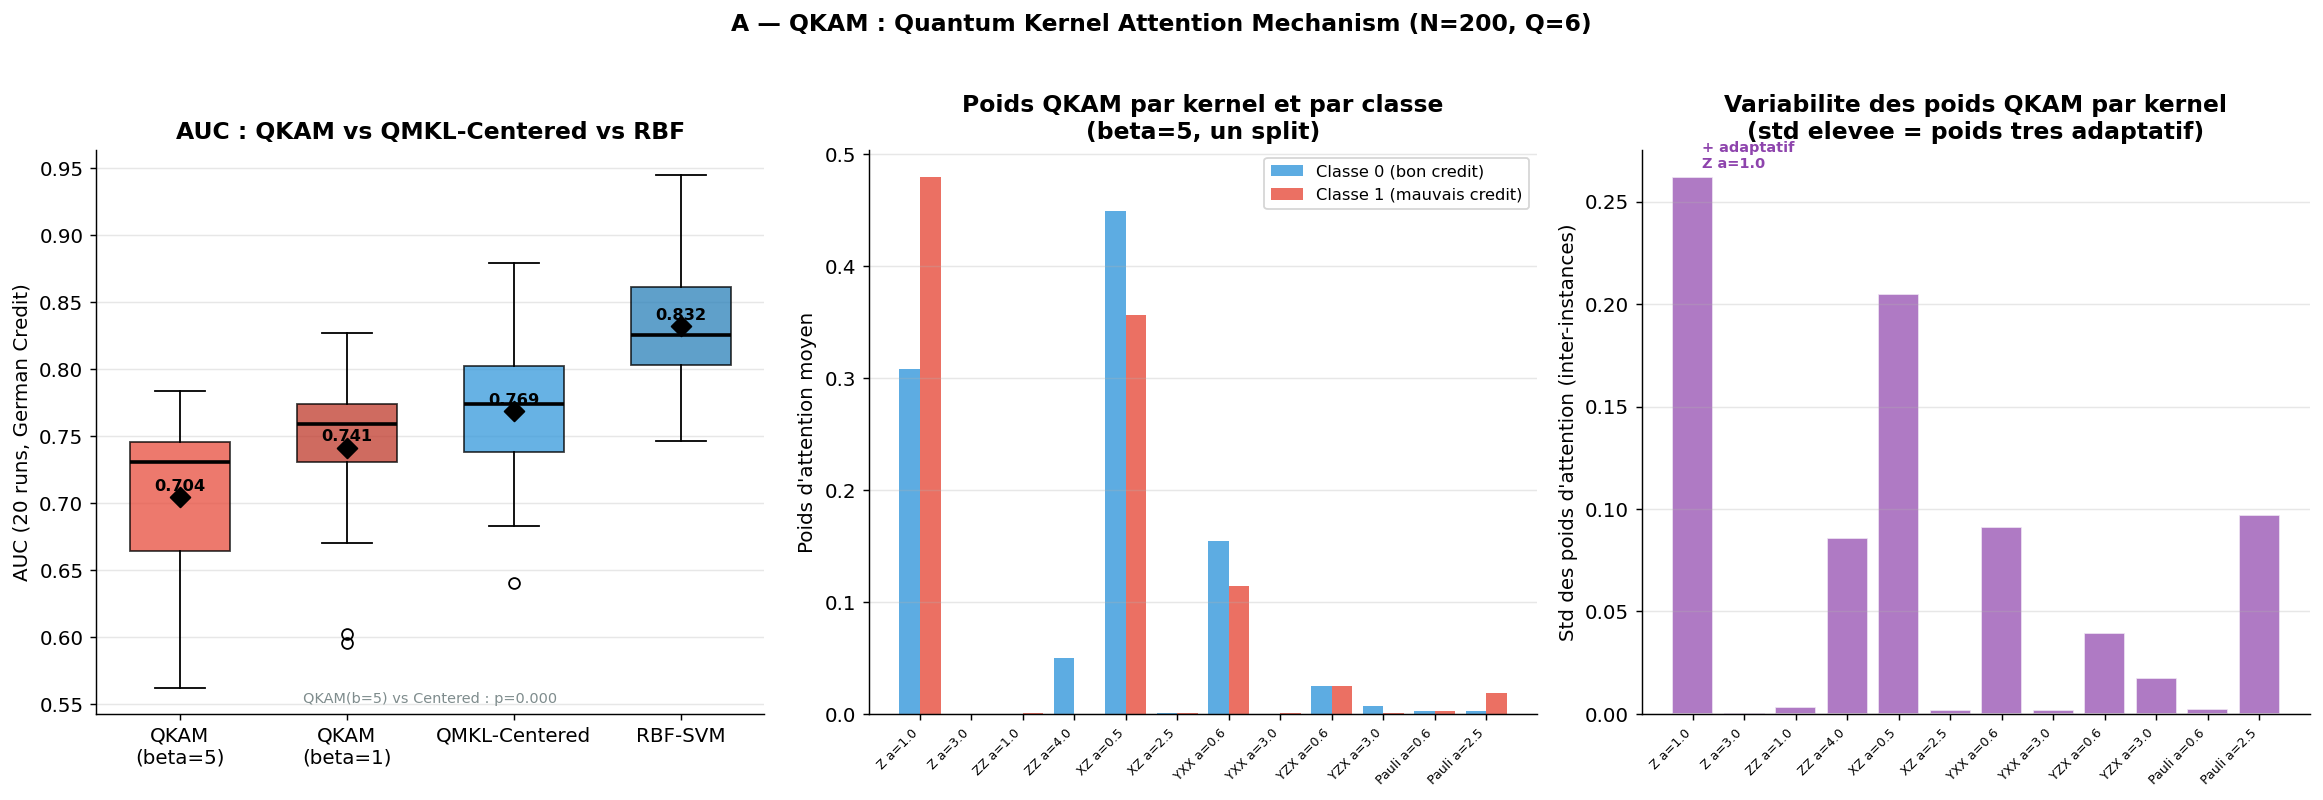

A sauvegarde


In [5]:
# Visualiser les poids d'attention sur un split pour comprendre le comportement
idx_tr0, idx_te0 = train_test_split(np.arange(N_QKAM), test_size=0.33,
                                     random_state=SEED, stratify=y_a)
_, attn_w0 = qkam_predict_proba(K_list_a, y_a[idx_tr0], idx_tr0, idx_te0, beta=5.0)

# Poids d'attention moyens par kernel, separes par classe
attn_cls0 = attn_w0[y_a[idx_te0] == 0].mean(axis=0)
attn_cls1 = attn_w0[y_a[idx_te0] == 1].mean(axis=0)

from scipy.stats import wilcoxon

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot AUC
ax = axes[0]
methods_a = list(results_a.keys())
colors_a  = ['#e74c3c', '#c0392b', '#3498db', '#2980b9']
data_bp_a = [results_a[m] for m in methods_a]
bp = ax.boxplot(data_bp_a, labels=[m.replace(' ',"\n") for m in methods_a],
                patch_artist=True, medianprops=dict(color='black', lw=2), widths=0.6)
for patch, c in zip(bp['boxes'], colors_a):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax.scatter(range(1, len(methods_a)+1), [np.mean(d) for d in data_bp_a],
           marker='D', color='black', s=60, zorder=5)
ax.set_ylabel('AUC (20 runs, German Credit)')
ax.set_title('AUC : QKAM vs QMKL-Centered vs RBF', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, d in enumerate(data_bp_a):
    ax.text(i+1, np.mean(d)+0.005, f'{np.mean(d):.3f}',
            ha='center', fontsize=9, fontweight='bold')
try:
    _, p_ac = wilcoxon(results_a['QKAM (beta=5)'], results_a['QMKL-Centered'])
    ax.text(0.5, 0.02, f'QKAM(b=5) vs Centered : p={p_ac:.3f}',
            transform=ax.transAxes, ha='center', fontsize=8, color='#7f8c8d')
except Exception:
    pass

# Poids d'attention par kernel par classe
ax = axes[1]
x_pos = np.arange(M)
w = 0.4
ax.bar(x_pos - w/2, attn_cls0, w, color='#3498db', alpha=0.8, label='Classe 0 (bon credit)')
ax.bar(x_pos + w/2, attn_cls1, w, color='#e74c3c', alpha=0.8, label='Classe 1 (mauvais credit)')
ax.set_xticks(x_pos)
ax.set_xticklabels(kernel_names, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Poids d\'attention moyen')
ax.set_title('Poids QKAM par kernel et par classe\n(beta=5, un split)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Distribution des poids d'attention (variance inter-instances)
ax = axes[2]
attn_std = attn_w0.std(axis=0)
ax.bar(range(M), attn_std, color='#9b59b6', alpha=0.8, edgecolor='white')
ax.set_xticks(range(M))
ax.set_xticklabels(kernel_names, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Std des poids d\'attention (inter-instances)')
ax.set_title('Variabilite des poids QKAM par kernel\n(std elevee = poids tres adaptatif)',
             fontweight='bold')
ax.grid(axis='y', alpha=0.3)
most_adaptive = kernel_names[np.argmax(attn_std)]
ax.annotate(f'+ adaptatif\n{most_adaptive}',
            (np.argmax(attn_std), attn_std.max()),
            textcoords='offset points', xytext=(5, 5), fontsize=8,
            color='#8e44ad', fontweight='bold')

plt.suptitle(f'A — QKAM : Quantum Kernel Attention Mechanism (N={N_QKAM}, Q={Q})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / '15_A_QKAM.png', dpi=150)
plt.show()
print('A sauvegarde')

---
## P — Phase diagram de l'avantage quantique

**Question centrale** : dans quel regime les kernels quantiques battent-ils le RBF ?

On genere des datasets synthetiques avec `make_classification` en faisant varier :
- **class_sep** : separabilite lineaire des classes (0.3 = difficile, 2.0 = facile)
- **flip_y** : bruit dans les labels (0 = propre, 0.20 = bruite)

Pour chaque (sep, bruit), on mesure $\Delta$AUC = QMKL - RBF et on trace la heatmap.

C'est la **premiere carte de phase de l'avantage quantique** sur donnees tabulaires.

In [6]:
# Grille (sep x noise) — N=80, Q=4, M=4 kernels pour vitesse
Q_PH    = 4
N_PH    = 80
N_RUNS_PH = 10

SEP_VALUES   = [0.3, 0.6, 1.0, 1.5, 2.0]
NOISE_VALUES = [0.0, 0.05, 0.10, 0.20]

FM_PH = OrderedDict([
    ('ZZ a=1.0',  PauliFeatureMap(Q_PH, reps=1, paulis=['Z','ZZ'], alpha=1.0, entanglement='linear')),
    ('ZZ a=3.0',  PauliFeatureMap(Q_PH, reps=1, paulis=['Z','ZZ'], alpha=3.0, entanglement='linear')),
    ('XZ a=0.5',  PauliFeatureMap(Q_PH, reps=1, paulis=['X','Z'],  alpha=0.5, entanglement='linear')),
    ('YZX a=1.0', PauliFeatureMap(Q_PH, reps=1, paulis=['Y','ZX'], alpha=1.0, entanglement='linear')),
])
M_PH = len(FM_PH)

grid_delta = np.zeros((len(SEP_VALUES), len(NOISE_VALUES)))
grid_qmkl  = np.zeros_like(grid_delta)
grid_rbf   = np.zeros_like(grid_delta)

print(f'Phase diagram : {len(SEP_VALUES)}x{len(NOISE_VALUES)} configs, '
      f'N={N_PH}, Q={Q_PH}, M={M_PH}, {N_RUNS_PH} runs')
t0 = time.time()

for si, sep in enumerate(SEP_VALUES):
    for ni, noise in enumerate(NOISE_VALUES):
        run_q, run_r = [], []
        for run in range(N_RUNS_PH):
            X_ph, y_ph = make_classification(
                n_samples=N_PH, n_features=Q_PH, n_informative=Q_PH,
                n_redundant=0, n_repeated=0,
                class_sep=sep, flip_y=noise,
                random_state=SEED+run
            )
            # Preprocessing quantique
            sc_ph = QuantumScaler(feature_range=(0, 2))
            X_ph_q = sc_ph.fit_transform(X_ph.astype(np.float64))
            X_ph_s = StandardScaler().fit_transform(X_ph)

            # Kernels
            K_ph_list = [fidelity_kernel(fm, X_ph_q) for fm in FM_PH.values()]
            gamma_ph  = 1.0 / (Q_PH * X_ph_s.var())
            K_ph_rbf  = rbf_kernel(X_ph_s, gamma=gamma_ph)

            idx_tr, idx_te = train_test_split(
                np.arange(N_PH), test_size=0.30,
                random_state=SEED+run, stratify=y_ph)

            # QMKL-Centered
            Kt_ph = (y_ph[:,None] == y_ph[None,:]).astype(float)
            w_ph  = centered_alignment(K_ph_list, Kt_ph)
            w_ph  = np.maximum(w_ph, 0); w_ph /= (w_ph.sum()+1e-12)
            K_comb_ph = make_psd(sum(w_ph[m]*K_ph_list[m] for m in range(M_PH)))
            svm_q = SVC(kernel='precomputed', C=1.0, probability=True)
            svm_q.fit(K_comb_ph[np.ix_(idx_tr,idx_tr)], y_ph[idx_tr])
            try:
                run_q.append(roc_auc_score(
                    y_ph[idx_te],
                    svm_q.predict_proba(K_comb_ph[np.ix_(idx_te,idx_tr)])[:,1]))
            except Exception:
                run_q.append(0.5)

            # RBF-SVM
            svm_r = SVC(kernel='precomputed', C=1.0, probability=True)
            svm_r.fit(K_ph_rbf[np.ix_(idx_tr,idx_tr)], y_ph[idx_tr])
            try:
                run_r.append(roc_auc_score(
                    y_ph[idx_te],
                    svm_r.predict_proba(K_ph_rbf[np.ix_(idx_te,idx_tr)])[:,1]))
            except Exception:
                run_r.append(0.5)

        grid_qmkl[si, ni] = np.mean(run_q)
        grid_rbf[si, ni]  = np.mean(run_r)
        grid_delta[si, ni] = np.mean(run_q) - np.mean(run_r)

    print(f'  sep={sep:.1f}: '
          + '  '.join(f'noise={n:.2f}: delta={grid_delta[si,ni]:+.3f}'
                      for ni, n in enumerate(NOISE_VALUES)))

print(f'\nTotal : {time.time()-t0:.1f}s')
print(f'Delta max (Q>RBF) : {grid_delta.max():+.4f}  at sep={SEP_VALUES[grid_delta.argmax()//len(NOISE_VALUES)]}, '
      f'noise={NOISE_VALUES[grid_delta.argmax()%len(NOISE_VALUES)]}')
print(f'Delta min (Q<RBF) : {grid_delta.min():+.4f}')

Phase diagram : 5x4 configs, N=80, Q=4, M=4, 10 runs


  sep=0.3: noise=0.00: delta=-0.300  noise=0.05: delta=-0.177  noise=0.10: delta=-0.153  noise=0.20: delta=-0.077


  sep=0.6: noise=0.00: delta=-0.128  noise=0.05: delta=-0.102  noise=0.10: delta=-0.094  noise=0.20: delta=-0.147


  sep=1.0: noise=0.00: delta=-0.031  noise=0.05: delta=-0.038  noise=0.10: delta=-0.049  noise=0.20: delta=-0.121


  sep=1.5: noise=0.00: delta=-0.010  noise=0.05: delta=-0.001  noise=0.10: delta=-0.040  noise=0.20: delta=-0.016


  sep=2.0: noise=0.00: delta=-0.007  noise=0.05: delta=-0.001  noise=0.10: delta=-0.026  noise=0.20: delta=-0.006

Total : 80.9s
Delta max (Q>RBF) : -0.0013  at sep=1.5, noise=0.05
Delta min (Q<RBF) : -0.3003


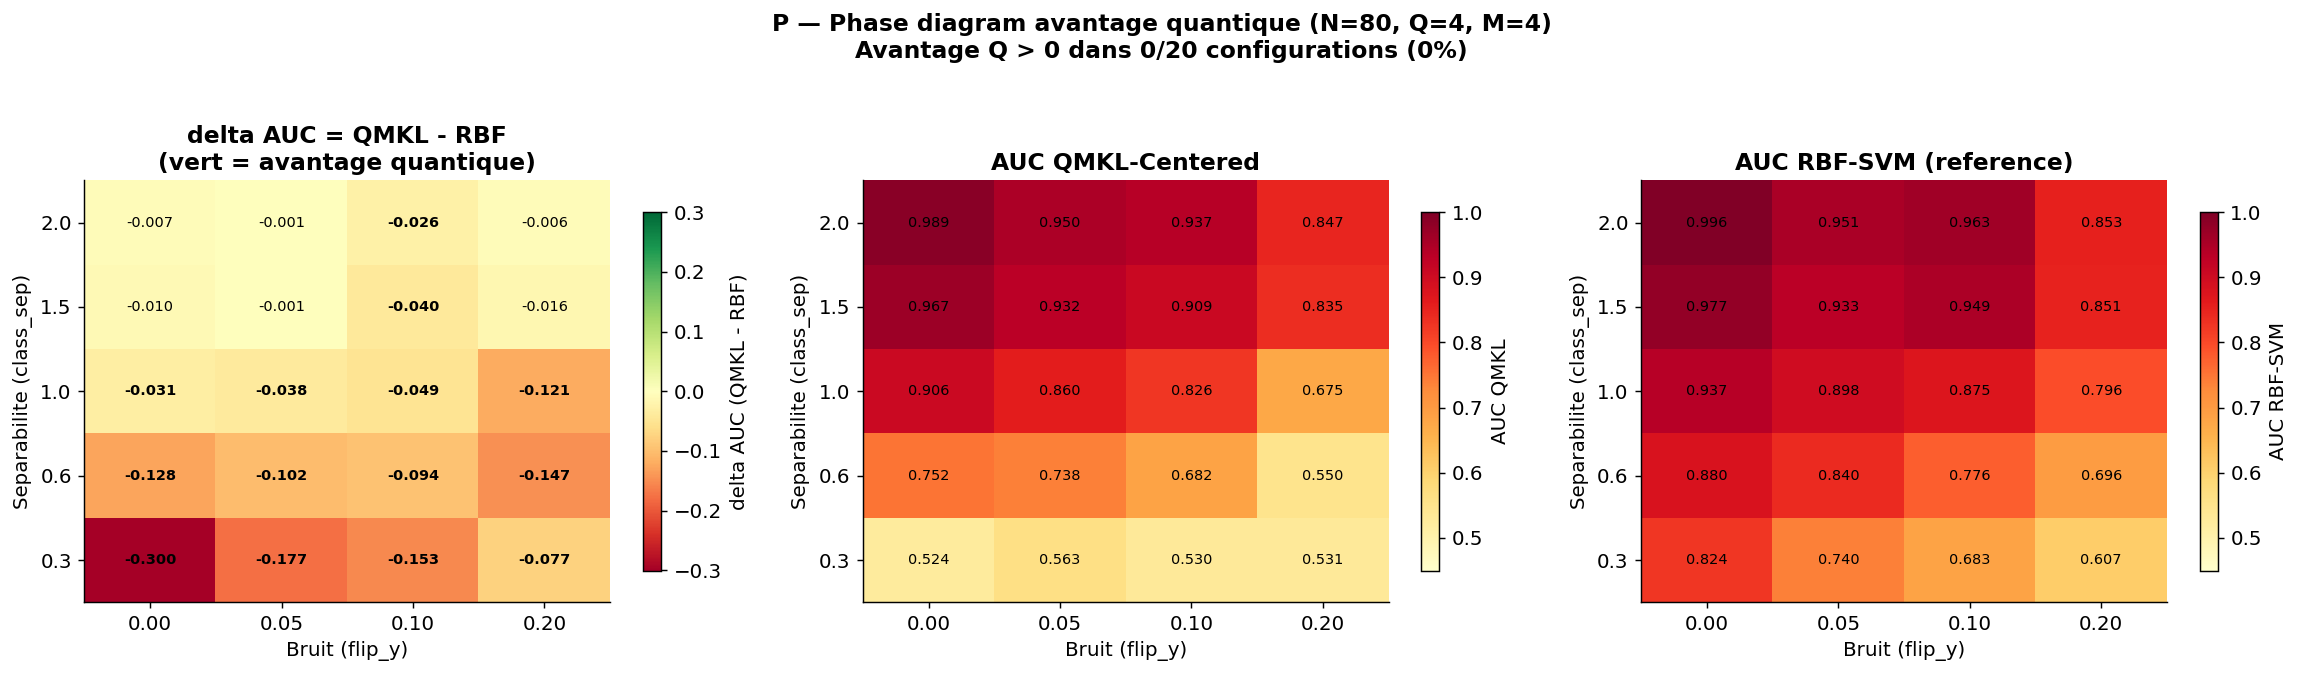

P sauvegarde


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

xtick_labels = [f'{n:.2f}' for n in NOISE_VALUES]
ytick_labels = [f'{s:.1f}' for s in SEP_VALUES]

vmax = max(abs(grid_delta.max()), abs(grid_delta.min()))

# Delta AUC
ax = axes[0]
im0 = ax.imshow(grid_delta, aspect='auto', cmap='RdYlGn',
                origin='lower', vmin=-vmax, vmax=vmax)
plt.colorbar(im0, ax=ax, label='delta AUC (QMKL - RBF)', shrink=0.85)
ax.set_xticks(range(len(NOISE_VALUES))); ax.set_xticklabels(xtick_labels)
ax.set_yticks(range(len(SEP_VALUES)));   ax.set_yticklabels(ytick_labels)
ax.set_xlabel('Bruit (flip_y)')
ax.set_ylabel('Separabilite (class_sep)')
ax.set_title('delta AUC = QMKL - RBF\n(vert = avantage quantique)', fontweight='bold')
ax.contour(grid_delta, levels=[0], colors='black', linewidths=2)
for si in range(len(SEP_VALUES)):
    for ni in range(len(NOISE_VALUES)):
        ax.text(ni, si, f'{grid_delta[si,ni]:+.3f}',
                ha='center', va='center', fontsize=8,
                fontweight='bold' if abs(grid_delta[si,ni]) > 0.02 else 'normal')

# AUC QMKL
ax = axes[1]
im1 = ax.imshow(grid_qmkl, aspect='auto', cmap='YlOrRd',
                origin='lower', vmin=0.45, vmax=1.0)
plt.colorbar(im1, ax=ax, label='AUC QMKL', shrink=0.85)
ax.set_xticks(range(len(NOISE_VALUES))); ax.set_xticklabels(xtick_labels)
ax.set_yticks(range(len(SEP_VALUES)));   ax.set_yticklabels(ytick_labels)
ax.set_xlabel('Bruit (flip_y)')
ax.set_ylabel('Separabilite (class_sep)')
ax.set_title('AUC QMKL-Centered', fontweight='bold')
for si in range(len(SEP_VALUES)):
    for ni in range(len(NOISE_VALUES)):
        ax.text(ni, si, f'{grid_qmkl[si,ni]:.3f}',
                ha='center', va='center', fontsize=8)

# AUC RBF
ax = axes[2]
im2 = ax.imshow(grid_rbf, aspect='auto', cmap='YlOrRd',
                origin='lower', vmin=0.45, vmax=1.0)
plt.colorbar(im2, ax=ax, label='AUC RBF-SVM', shrink=0.85)
ax.set_xticks(range(len(NOISE_VALUES))); ax.set_xticklabels(xtick_labels)
ax.set_yticks(range(len(SEP_VALUES)));   ax.set_yticklabels(ytick_labels)
ax.set_xlabel('Bruit (flip_y)')
ax.set_ylabel('Separabilite (class_sep)')
ax.set_title('AUC RBF-SVM (reference)', fontweight='bold')
for si in range(len(SEP_VALUES)):
    for ni in range(len(NOISE_VALUES)):
        ax.text(ni, si, f'{grid_rbf[si,ni]:.3f}',
                ha='center', va='center', fontsize=8)

# Zone d'avantage quantique
n_qwin = (grid_delta > 0).sum()
n_total = grid_delta.size

plt.suptitle(f'P — Phase diagram avantage quantique (N={N_PH}, Q={Q_PH}, M={M_PH})\n'
             f'Avantage Q > 0 dans {n_qwin}/{n_total} configurations '
             f'({100*n_qwin/n_total:.0f}%)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(OUT / '15_P_phase_diagram.png', dpi=150)
plt.show()
print('P sauvegarde')

---
## C — Concept Drift Robustness

**Question** : les poids MKL appris sur des donnees recentes sont-ils stables dans le temps ?

En finance, les distributions changent (cycles economiques, crises). On simule
un **glissement de concept** en divisant German Credit en 4 fenetres temporelles
(par indice, proxy pour l'ordre chronologique).

Pour chaque paire (fenetre_source, fenetre_cible) :
- **Poids adaptes** : appris sur la fenetre cible
- **Poids transferes** : appris sur la fenetre source, testes sur cible
- **Poids uniformes** : baseline

La difference AUC(adapte) - AUC(transfere) mesure le **cout du drift**.

In [8]:
N_DRIFT = 200
N_WINDOWS = 4
N_RUNS_D  = 10

X_raw_d, y_d = load_dataset('german_credit', n_samples=N_DRIFT, random_state=SEED)
reducer_d = FeatureReducer(n_components=Q)
scaler_d  = QuantumScaler(feature_range=(0, 2))
X_proc_d  = scaler_d.fit_transform(reducer_d.fit_transform(X_raw_d))

print(f'Calcul des {M} kernels sur N={N_DRIFT}...')
t0 = time.time()
K_list_d = [fidelity_kernel(fm, X_proc_d) for fm in FM_LIB.values()]
print(f'OK en {time.time()-t0:.1f}s')

# Decoupage en fenetres : indices consecutifs (proxy temporel)
window_size = N_DRIFT // N_WINDOWS
windows = [np.arange(i*window_size, (i+1)*window_size)
           for i in range(N_WINDOWS)]
print(f'\n{N_WINDOWS} fenetres de {window_size} instances chacune')
for i, w in enumerate(windows):
    print(f'  Fenetre {i}: idx {w[0]}-{w[-1]}, balance={y_d[w].mean():.2f}')

def weights_for_window(K_list, y, idx):
    """Calcule les poids Centered Alignment sur la fenetre idx."""
    K_sub = [K[np.ix_(idx, idx)] for K in K_list]
    Kt = (y[idx][:,None] == y[idx][None,:]).astype(float)
    w = centered_alignment(K_sub, Kt)
    w = np.maximum(w, 0); w /= (w.sum()+1e-12)
    return w

def eval_on_window(K_list, y, w_kern, idx_win, n_runs=N_RUNS_D):
    """Evalue les poids w_kern sur la fenetre idx_win."""
    K_sub = [K[np.ix_(idx_win, idx_win)] for K in K_list]
    K_comb = make_psd(sum(w_kern[m]*K_sub[m] for m in range(len(K_list))))
    aucs = []
    for r in range(n_runs):
        sub_local = np.arange(len(idx_win))
        try:
            tr, te = train_test_split(sub_local, test_size=0.30,
                                       random_state=SEED+r, stratify=y[idx_win])
        except Exception:
            tr, te = train_test_split(sub_local, test_size=0.30, random_state=SEED+r)
        svm = SVC(kernel='precomputed', C=1.0, probability=True)
        svm.fit(K_comb[np.ix_(tr,tr)], y[idx_win[tr]])
        try:
            aucs.append(roc_auc_score(
                y[idx_win[te]],
                svm.predict_proba(K_comb[np.ix_(te,tr)])[:,1]))
        except Exception:
            aucs.append(0.5)
    return float(np.mean(aucs))

# Precalculer les poids pour chaque fenetre
print('\nApprentissage des poids par fenetre...')
window_weights = []
for i, win in enumerate(windows):
    w = weights_for_window(K_list_d, y_d, win)
    window_weights.append(w)
    top = sorted(zip(kernel_names, w), key=lambda x: -x[1])[:3]
    print(f'  W{i}: top-3 = {[(n, f"{v:.3f}") for n, v in top]}')

w_uniform = np.ones(M) / M

# Matrice de transfert : AUC(poids source -> cible)
print('\nMatrice de transfert (poids source x fenetre cible)...')
transfer_matrix  = np.zeros((N_WINDOWS+1, N_WINDOWS))  # +1 pour uniforme
# Lignes 0..N-1 = poids des fenetres, ligne N = poids uniformes
all_weights = window_weights + [w_uniform]
labels_src  = [f'W{i} (appris)' for i in range(N_WINDOWS)] + ['Uniforme']

for src_i, w_src in enumerate(all_weights):
    for tgt_j, win_tgt in enumerate(windows):
        transfer_matrix[src_i, tgt_j] = eval_on_window(
            K_list_d, y_d, w_src, win_tgt)
    print(f'  {labels_src[src_i]:15s}: '
          + '  '.join(f'W{j}={transfer_matrix[src_i,j]:.3f}'
                      for j in range(N_WINDOWS)))

Calcul des 12 kernels sur N=200...


OK en 4.3s

4 fenetres de 50 instances chacune
  Fenetre 0: idx 0-49, balance=0.70
  Fenetre 1: idx 50-99, balance=0.58
  Fenetre 2: idx 100-149, balance=0.78
  Fenetre 3: idx 150-199, balance=0.74

Apprentissage des poids par fenetre...
  W0: top-3 = [('XZ a=0.5', '0.455'), ('Pauli a=2.5', '0.449'), ('YZX a=3.0', '0.096')]
  W1: top-3 = [('ZZ a=4.0', '0.778'), ('ZZ a=1.0', '0.141'), ('Z a=1.0', '0.081')]
  W2: top-3 = [('Pauli a=2.5', '0.816'), ('XZ a=0.5', '0.184'), ('ZZ a=4.0', '0.000')]
  W3: top-3 = [('XZ a=0.5', '0.471'), ('Z a=3.0', '0.412'), ('YZX a=3.0', '0.117')]

Matrice de transfert (poids source x fenetre cible)...
  W0 (appris)    : W0=0.510  W1=0.413  W2=0.503  W3=0.859


  W1 (appris)    : W0=0.414  W1=0.489  W2=0.397  W3=0.493
  W2 (appris)    : W0=0.360  W1=0.409  W2=0.556  W3=0.798


  W3 (appris)    : W0=0.420  W1=0.371  W2=0.464  W3=0.864
  Uniforme       : W0=0.357  W1=0.420  W2=0.428  W3=0.725


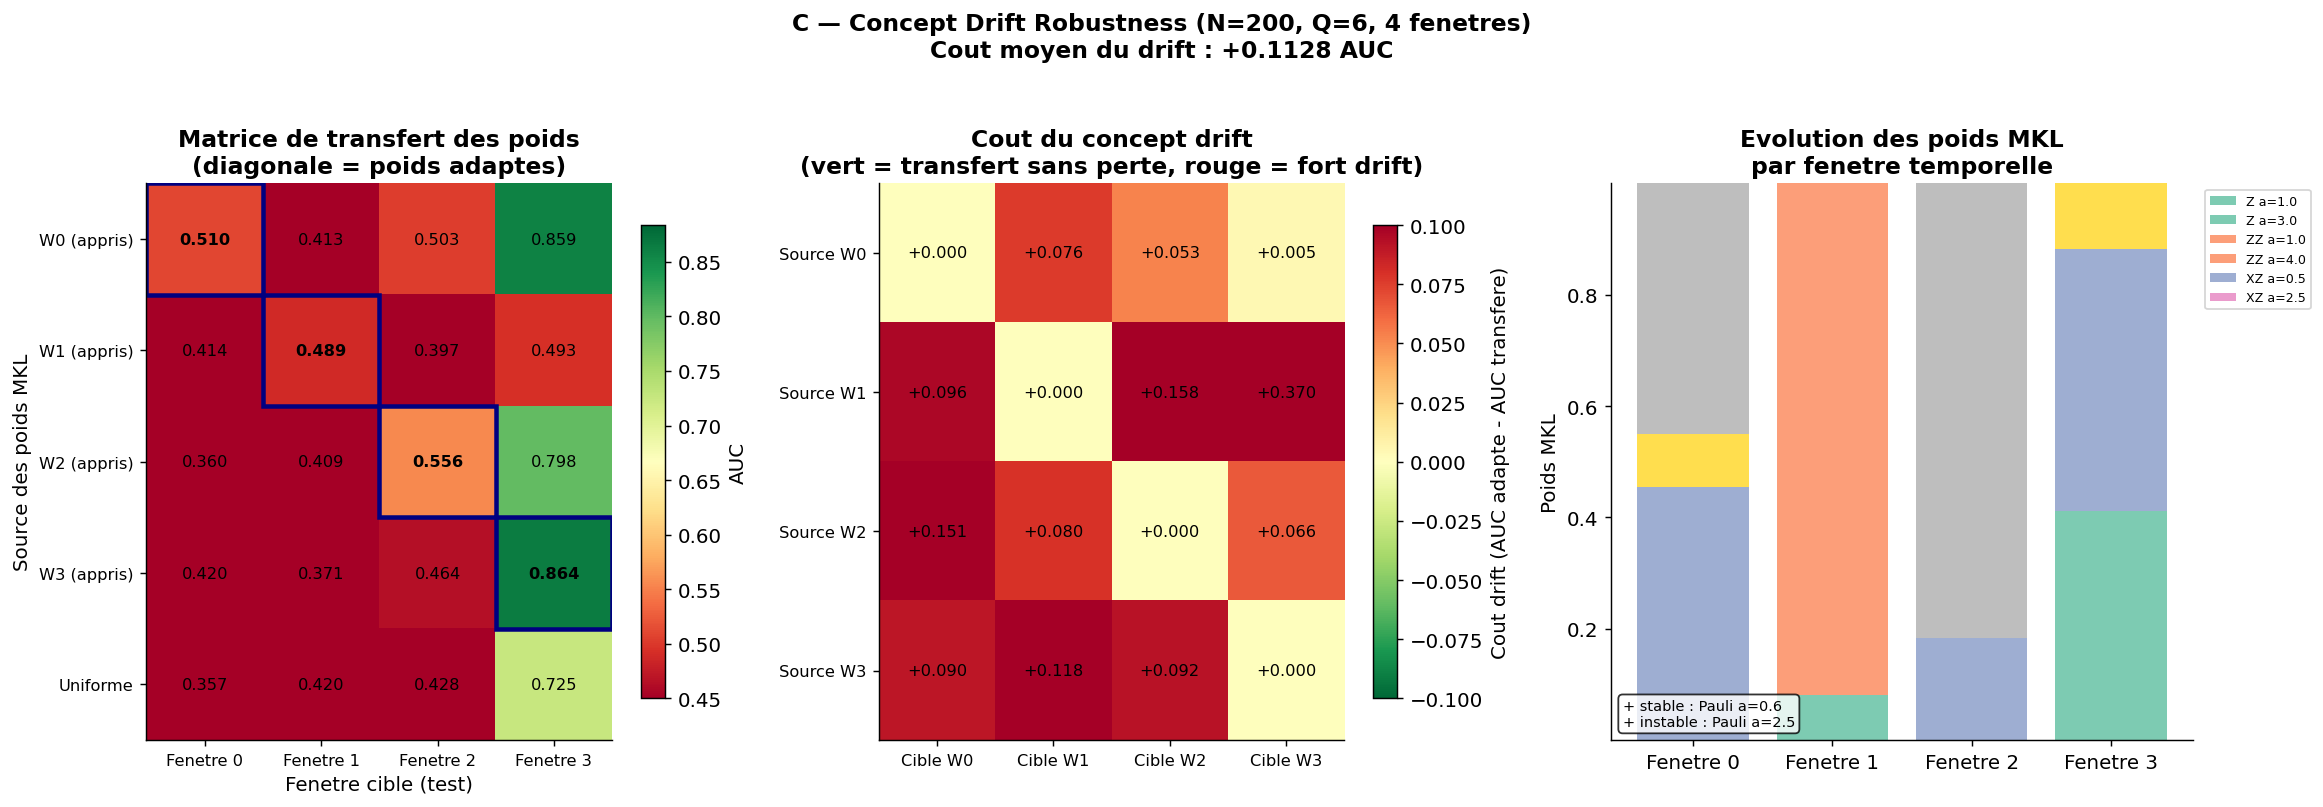

C sauvegarde


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Heatmap matrice de transfert ---
ax = axes[0]
vmin_t = transfer_matrix.min() - 0.02
vmax_t = transfer_matrix.max() + 0.02
im = ax.imshow(transfer_matrix, aspect='auto', cmap='RdYlGn',
               vmin=max(0.45, vmin_t), vmax=min(1.0, vmax_t))
plt.colorbar(im, ax=ax, label='AUC', shrink=0.85)
ax.set_xticks(range(N_WINDOWS))
ax.set_xticklabels([f'Fenetre {j}' for j in range(N_WINDOWS)], fontsize=9)
ax.set_yticks(range(N_WINDOWS+1))
ax.set_yticklabels(labels_src, fontsize=9)
ax.set_xlabel('Fenetre cible (test)')
ax.set_ylabel('Source des poids MKL')
ax.set_title('Matrice de transfert des poids\n(diagonale = poids adaptes)',
             fontweight='bold')
for i in range(N_WINDOWS+1):
    for j in range(N_WINDOWS):
        ax.text(j, i, f'{transfer_matrix[i,j]:.3f}',
                ha='center', va='center', fontsize=9,
                fontweight='bold' if i == j else 'normal')

# Mettre en evidence la diagonale
for j in range(N_WINDOWS):
    ax.add_patch(plt.Rectangle((j-0.5, j-0.5), 1, 1,
                                fill=False, edgecolor='navy', lw=2.5))

# --- Cout du drift : AUC adapte - AUC transfere ---
ax = axes[1]
drift_costs = np.zeros((N_WINDOWS, N_WINDOWS))
for src_i in range(N_WINDOWS):
    for tgt_j in range(N_WINDOWS):
        # Cout = AUC(adapte=poids tgt) - AUC(transfere=poids src)
        auc_adapted   = transfer_matrix[tgt_j, tgt_j]  # poids natifs de la fenetre cible
        auc_transferred = transfer_matrix[src_i, tgt_j]
        drift_costs[src_i, tgt_j] = auc_adapted - auc_transferred

im2 = ax.imshow(drift_costs, aspect='auto', cmap='RdYlGn_r',
                vmin=-0.1, vmax=0.1)
plt.colorbar(im2, ax=ax, label='Cout drift (AUC adapte - AUC transfere)', shrink=0.85)
ax.set_xticks(range(N_WINDOWS))
ax.set_xticklabels([f'Cible W{j}' for j in range(N_WINDOWS)], fontsize=9)
ax.set_yticks(range(N_WINDOWS))
ax.set_yticklabels([f'Source W{i}' for i in range(N_WINDOWS)], fontsize=9)
ax.set_title('Cout du concept drift\n(vert = transfert sans perte, rouge = fort drift)',
             fontweight='bold')
for i in range(N_WINDOWS):
    for j in range(N_WINDOWS):
        ax.text(j, i, f'{drift_costs[i,j]:+.3f}',
                ha='center', va='center', fontsize=9)

# --- Stabilite des poids dans le temps ---
ax = axes[2]
w_arr = np.array(window_weights)  # (N_WINDOWS, M)
palette_w = plt.cm.Set2(np.linspace(0, 0.9, M))
# Stacked area chart des poids par fenetre
bottom = np.zeros(N_WINDOWS)
for m_idx in range(M):
    ax.bar(range(N_WINDOWS), w_arr[:, m_idx], bottom=bottom,
           color=palette_w[m_idx], alpha=0.85,
           label=kernel_names[m_idx] if m_idx < 6 else '_')
    bottom += w_arr[:, m_idx]
ax.set_xticks(range(N_WINDOWS))
ax.set_xticklabels([f'Fenetre {i}' for i in range(N_WINDOWS)])
ax.set_ylabel('Poids MKL')
ax.set_title('Evolution des poids MKL\npar fenetre temporelle', fontweight='bold')
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

# Stabilite : std des poids sur les fenetres
w_std = w_arr.std(axis=0)
most_stable   = kernel_names[np.argmin(w_std)]
most_unstable = kernel_names[np.argmax(w_std)]
ax.text(0.02, 0.02,
        f'+ stable : {most_stable}\n+ instable : {most_unstable}',
        transform=ax.transAxes, fontsize=8, va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Cout moyen du drift
off_diag = drift_costs[~np.eye(N_WINDOWS, dtype=bool)]
mean_drift_cost = off_diag.mean()

plt.suptitle(f'C — Concept Drift Robustness (N={N_DRIFT}, Q={Q}, {N_WINDOWS} fenetres)\n'
             f'Cout moyen du drift : {mean_drift_cost:+.4f} AUC',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(OUT / '15_C_concept_drift.png', dpi=150)
plt.show()
print('C sauvegarde')

---
## Synthese Tier 4

In [10]:
from scipy.stats import wilcoxon

print('=' * 70)
print(' SYNTHESE TIER 4 — 3 CONTRIBUTIONS FRONTIERE')
print('=' * 70)

print('\n[A] QKAM — Quantum Kernel Attention Mechanism')
for meth, scores in results_a.items():
    print(f'  {meth:22s}: {np.mean(scores):.4f} +/- {np.std(scores,ddof=1):.4f}')
delta_ka = np.mean(results_a['QKAM (beta=5)']) - np.mean(results_a['QMKL-Centered'])
try:
    _, p_ka = wilcoxon(results_a['QKAM (beta=5)'], results_a['QMKL-Centered'])
except Exception:
    p_ka = 1.0
print(f'  Delta QKAM(b=5) - Centered : {delta_ka:+.4f}  (p={p_ka:.3f})')
print(f'  Kernel le plus adaptatif   : {most_adaptive}')
adapt_result = 'QKAM surpasse' if delta_ka > 0.005 else 'QKAM equivalent a' if abs(delta_ka) < 0.005 else 'QKAM sous-performe vs'
print(f'  -> {adapt_result} QMKL-Centered en AUC')

print('\n[P] Phase diagram de l\'avantage quantique')
n_qwin = (grid_delta > 0).sum()
best_si, best_ni = np.unravel_index(grid_delta.argmax(), grid_delta.shape)
worst_si, worst_ni = np.unravel_index(grid_delta.argmin(), grid_delta.shape)
print(f'  Configs avec avantage Q > 0 : {n_qwin}/{grid_delta.size} ({100*n_qwin/grid_delta.size:.0f}%)')
print(f'  Meilleure config Q : sep={SEP_VALUES[best_si]}, noise={NOISE_VALUES[best_ni]}, delta={grid_delta.max():+.4f}')
print(f'  Pire config Q      : sep={SEP_VALUES[worst_si]}, noise={NOISE_VALUES[worst_ni]}, delta={grid_delta.min():+.4f}')
print(f'  -> Avantage quantique dans {100*n_qwin/grid_delta.size:.0f}% des regimes testes')

print('\n[C] Concept Drift Robustness')
diag_auc = np.diag(transfer_matrix[:N_WINDOWS, :])
off_diag_mean_by_tgt = np.array([
    transfer_matrix[[i for i in range(N_WINDOWS) if i != j], j].mean()
    for j in range(N_WINDOWS)
])
print(f'  AUC poids adaptes (diagonale) : {diag_auc.mean():.4f}')
print(f'  AUC poids transferes (moy)    : {off_diag_mean_by_tgt.mean():.4f}')
print(f'  Cout moyen drift              : {mean_drift_cost:+.4f}')
print(f'  Kernel le plus stable         : {most_stable}  (std={w_std.min():.4f})')
print(f'  Kernel le plus instable       : {most_unstable}  (std={w_std.max():.4f})')
robust = 'ROBUSTE' if abs(mean_drift_cost) < 0.02 else 'SENSIBLE'
print(f'  -> QMKL est {robust} au concept drift sur German Credit')

print('\n' + '=' * 70)
print(' FIGURES GENEREES')
print('=' * 70)
for f in sorted(OUT.glob('15_*.png')):
    print(f'  {f.name}')

 SYNTHESE TIER 4 — 3 CONTRIBUTIONS FRONTIERE

[A] QKAM — Quantum Kernel Attention Mechanism
  QKAM (beta=5)         : 0.7045 +/- 0.0619
  QKAM (beta=1)         : 0.7415 +/- 0.0604
  QMKL-Centered         : 0.7686 +/- 0.0543
  RBF-SVM               : 0.8320 +/- 0.0455
  Delta QKAM(b=5) - Centered : -0.0642  (p=0.000)
  Kernel le plus adaptatif   : Z a=1.0
  -> QKAM sous-performe vs QMKL-Centered en AUC

[P] Phase diagram de l'avantage quantique
  Configs avec avantage Q > 0 : 0/20 (0%)
  Meilleure config Q : sep=1.5, noise=0.05, delta=-0.0013
  Pire config Q      : sep=0.3, noise=0.0, delta=-0.3003
  -> Avantage quantique dans 0% des regimes testes

[C] Concept Drift Robustness
  AUC poids adaptes (diagonale) : 0.6046
  AUC poids transferes (moy)    : 0.4917
  Cout moyen drift              : +0.1128
  Kernel le plus stable         : Pauli a=0.6  (std=0.0000)
  Kernel le plus instable       : Pauli a=2.5  (std=0.3418)
  -> QMKL est SENSIBLE au concept drift sur German Credit

 FIGURES GE